<a href="https://colab.research.google.com/github/Raoina/Spectra-2-Image/blob/main/notebooks/Image_Transformation/03_MTF_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/LUCAS.SOIL_corr.csv'

In [ ]:
import pandas as pd

df = pd.read_csv(file_path)

df.head()

/tmp/ipython-input-3672932280.py:3: DtypeWarning: Columns (1,2,4216,4231,4234,4237,4274) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Unnamed: 0,sample.ID,ID,date,spc.400,spc.400.5,spc.401,spc.401.5,spc.402,spc.402.5,...,WRBLV1,WRBADJ1,PARMADO1,PARMADO2,PARMADO3,PARMASE1,PARMASE2,PARMASE3,MIN_TOP,mineral
0,4,100,100,2011-01-24 16:02:25,0.831705,0.839111,0.846473,0.853773,0.860988,0.868098,...,CM,dy,3.0,31.0,310.0,5.0,56.0,561.0,KQ,mineral
1,5,1000,1000,2010-09-30 14:50:01,0.706027,0.714901,0.723727,0.732480,0.741142,0.749684,...,CM,dy,3.0,31.0,311.0,3.0,31.0,310.0,KQ,mineral
2,6,10000,10000,2010-10-19 12:06:16,0.666238,0.676472,0.686654,0.696757,0.706753,0.716615,...,CM,ca,2.0,21.0,214.0,0.0,0.0,0.0,MS,mineral
3,7,10001,10001,2010-10-19 15:00:01,0.698136,0.706548,0.714909,0.723197,0.731384,0.739448,...,CM,dy,3.0,31.0,310.0,4.0,42.0,420.0,KQ,mineral
4,8,10002,10002,2011-04-30 12:26:27,0.675433,0.684820,0.694163,0.703438,0.712620,0.721693,...,LV,ha,7.0,71.0,710.0,6.0,62.0,620.0,M,mineral


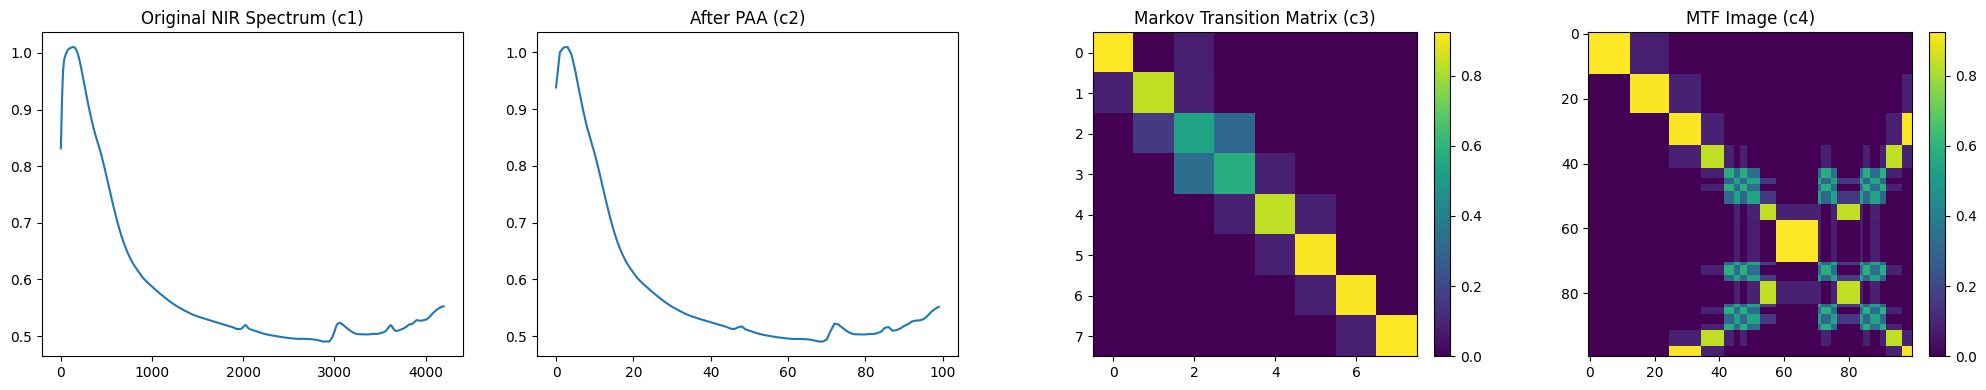

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

# ---------- 1. Example: take one spectrum ----------
row = df.iloc[0]
spectrum = row.filter(like="spc.")
intensity = spectrum.values.astype(float)

# ---------- 2. Apply PAA (reduce length) ----------
def paa(series, segments):
    n = len(series)
    win_size = n // segments
    return np.array([series[i*win_size:(i+1)*win_size].mean() for i in range(segments)])

paa_size = 100  # smaller sequence for demo
paa_series = paa(intensity, paa_size)

# ---------- 3. Discretization into Q states ----------
Q = 8  # number of quantile bins
scaler = KBinsDiscretizer(n_bins=Q, encode="ordinal", strategy="quantile")
discrete_seq = scaler.fit_transform(paa_series.reshape(-1, 1)).astype(int).flatten()

# ---------- 4. Build Markov transition matrix ----------
markov_matrix = np.zeros((Q, Q))
for (a, b) in zip(discrete_seq[:-1], discrete_seq[1:]):
    markov_matrix[a, b] += 1
# normalize to probabilities
markov_matrix = markov_matrix / markov_matrix.sum(axis=1, keepdims=True)

# ---------- 5. Build MTF image ----------
n = len(discrete_seq)
mtf = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        mtf[i, j] = markov_matrix[discrete_seq[i], discrete_seq[j]]

# ---------- 6. Visualization ----------
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

# (c1) Original NIR spectrum
axs[0].plot(intensity)
axs[0].set_title("Original NIR Spectrum (c1)")

# (c2) After PAA
axs[1].plot(paa_series)
axs[1].set_title("After PAA (c2)")

# (c3) Markov transition matrix
im1 = axs[2].imshow(markov_matrix, cmap="viridis")
axs[2].set_title("Markov Transition Matrix (c3)")
plt.colorbar(im1, ax=axs[2], fraction=0.046, pad=0.04)

# (c4) MTF Image
im2 = axs[3].imshow(mtf, cmap="viridis")
axs[3].set_title("MTF Image (c4)")
plt.colorbar(im2, ax=axs[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


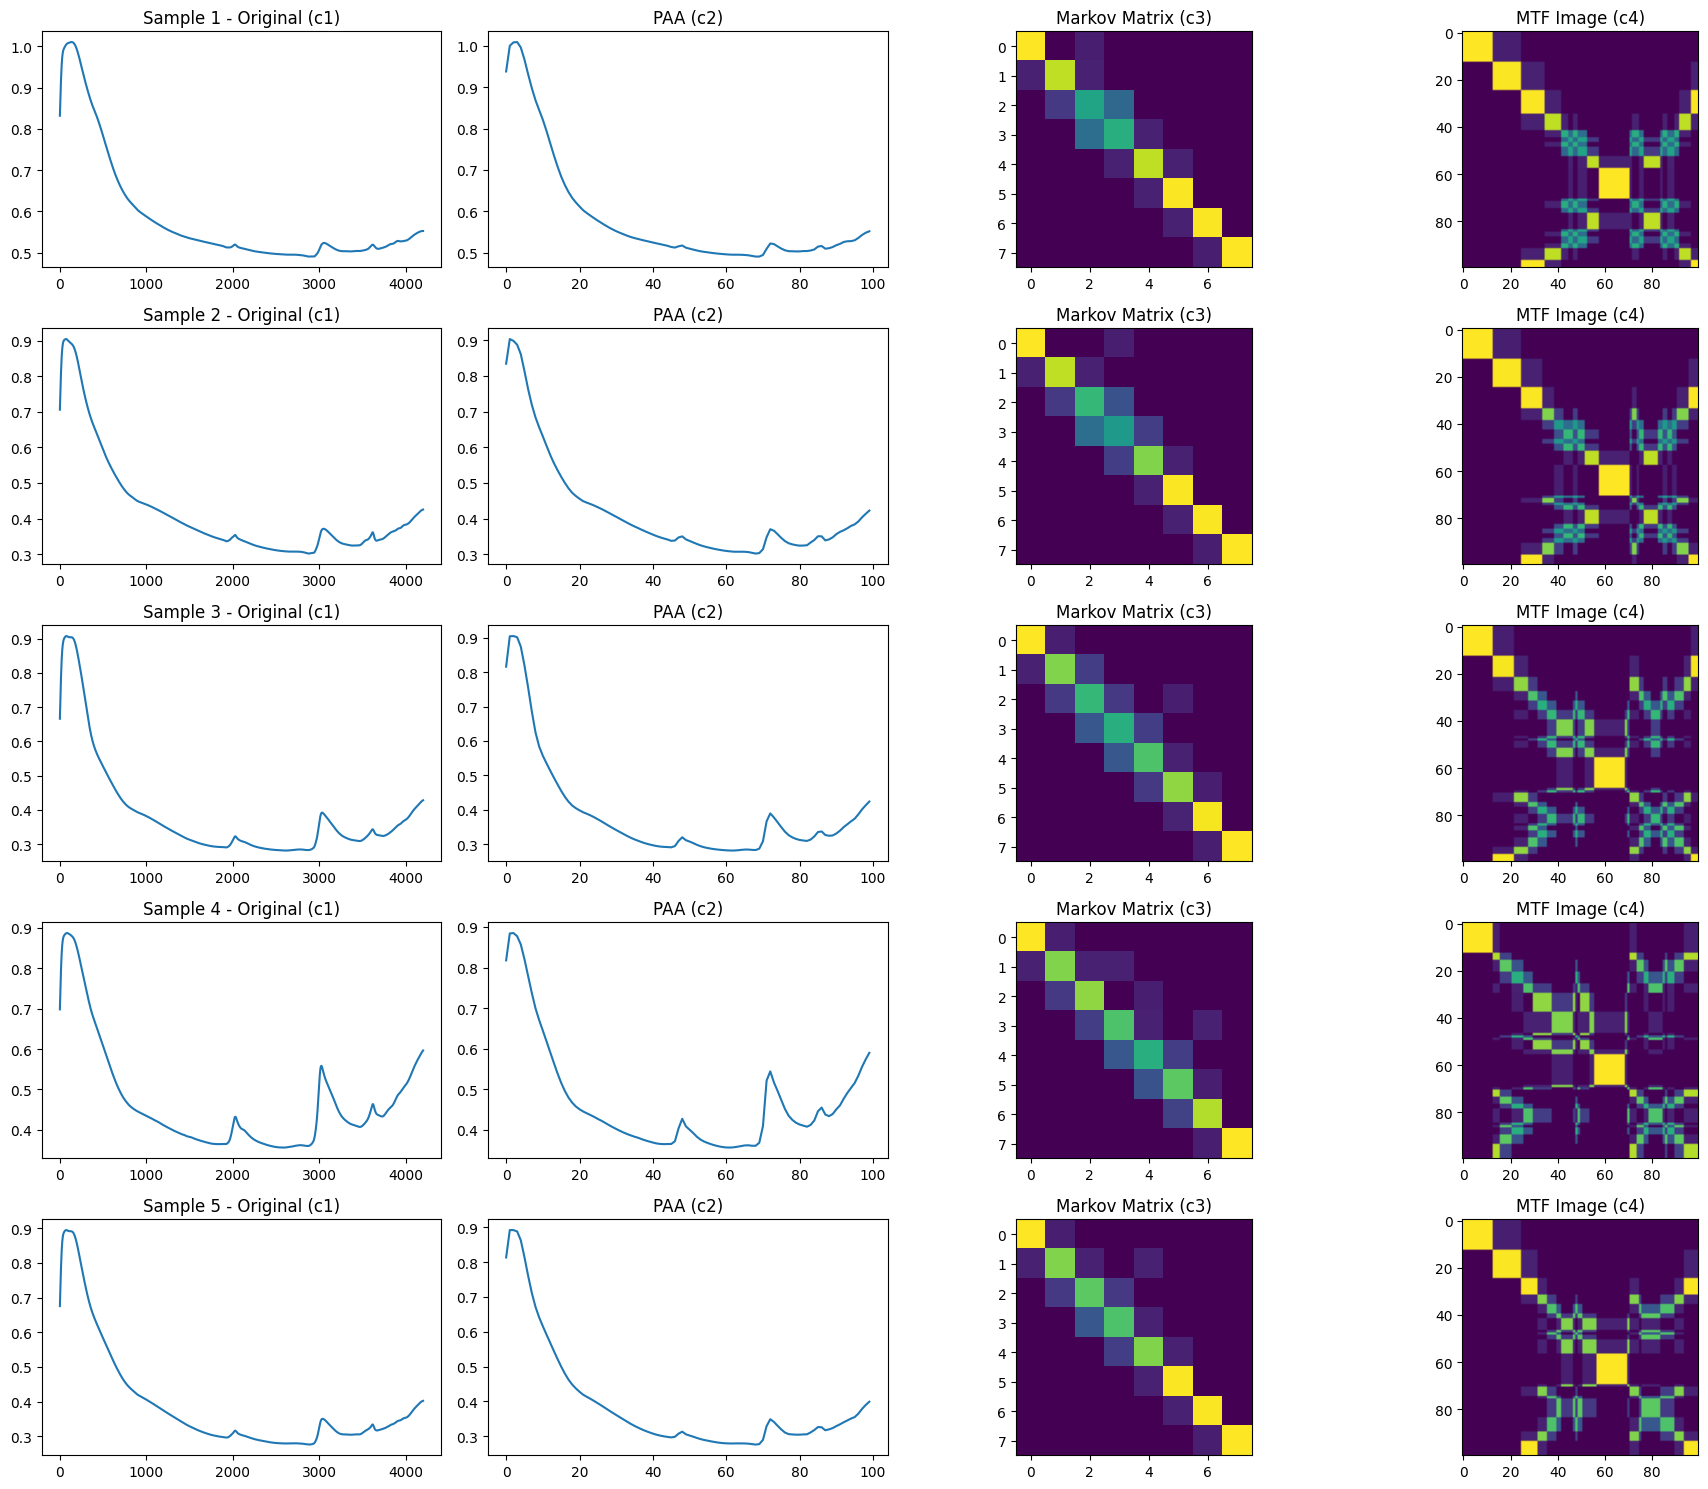

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

# ---------- Helper functions ----------
def paa(series, segments):
    """Piecewise Aggregate Approximation (PAA)."""
    n = len(series)
    win_size = n // segments
    return np.array([series[i*win_size:(i+1)*win_size].mean() for i in range(segments)])

def compute_mtf(series, paa_size=100, Q=8):
    """Compute Markov Transition Field (MTF) from a spectrum."""
    # 1) Apply PAA
    paa_series = paa(series, paa_size)

    # 2) Discretization into Q bins
    scaler = KBinsDiscretizer(n_bins=Q, encode="ordinal", strategy="quantile")
    discrete_seq = scaler.fit_transform(paa_series.reshape(-1, 1)).astype(int).flatten()

    # 3) Markov transition matrix
    markov_matrix = np.zeros((Q, Q))
    for (a, b) in zip(discrete_seq[:-1], discrete_seq[1:]):
        markov_matrix[a, b] += 1
    markov_matrix = markov_matrix / (markov_matrix.sum(axis=1, keepdims=True) + 1e-8)

    # 4) Build MTF image
    n = len(discrete_seq)
    mtf = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mtf[i, j] = markov_matrix[discrete_seq[i], discrete_seq[j]]

    return paa_series, markov_matrix, mtf

# ---------- Apply to first 5 samples ----------
num_samples = 5
samples = [df.iloc[i].filter(like="spc.").values.astype(float) for i in range(num_samples)]

fig, axs = plt.subplots(num_samples, 4, figsize=(18, 3*num_samples))

for idx, spectrum in enumerate(samples):
    paa_series, markov_matrix, mtf = compute_mtf(spectrum, paa_size=100, Q=8)

    # (c1) Original spectrum
    axs[idx, 0].plot(spectrum)
    axs[idx, 0].set_title(f"Sample {idx+1} - Original (c1)")

    # (c2) PAA sequence
    axs[idx, 1].plot(paa_series)
    axs[idx, 1].set_title("PAA (c2)")

    # (c3) Markov transition matrix
    im1 = axs[idx, 2].imshow(markov_matrix, cmap="viridis")
    axs[idx, 2].set_title("Markov Matrix (c3)")

    # (c4) MTF image
    im2 = axs[idx, 3].imshow(mtf, cmap="viridis")
    axs[idx, 3].set_title("MTF Image (c4)")

plt.tight_layout()
plt.show()
